# 01 — Analiza skupa podataka (EDA)

U ovom projektu koristimo dva skupa podataka:

- **Breast Cancer Wisconsin** — binarna klasifikacija (maligni/benigni tumor), 30 atributa
- **Digits** — prepoznavanje rukom pisanih cifara (0-9), 64 atributa (slika 8x8 piksela)


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

from sklearn.datasets import load_breast_cancer, load_digits

## 1. Učitavanje podataka

In [9]:
#učitavamo oba skupa podataka
breast_cancer = load_breast_cancer()
digits = load_digits()

X_bc = breast_cancer.data
y_bc = breast_cancer.target

X_dg = digits.data
y_dg = digits.target

print('Breast cancer:', X_bc.shape, '-> broj klasa:', len(np.unique(y_bc)))
print('Digits:       ', X_dg.shape, '-> broj klasa:', len(np.unique(y_dg)))

Breast cancer: (569, 30) -> broj klasa: 2
Digits:        (1797, 64) -> broj klasa: 10


## 2. Osnovne statistike i struktura

In [10]:
df_bc = pd.DataFrame(X_bc, columns=breast_cancer.feature_names)
df_bc['target'] = y_bc

print('Broj NaN vrednosti u breast cancer skupu:', df_bc.isna().sum().sum())

df_bc.describe().T.head(10)

Broj NaN vrednosti u breast cancer skupu: 0


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


In [11]:
df_dg = pd.DataFrame(X_dg)
df_dg['target'] = y_dg

print('Broj NaN vrednosti u digits skupu:', df_dg.isna().sum().sum())
print('Oblik digits skupa:', df_dg.shape)

Broj NaN vrednosti u digits skupu: 0
Oblik digits skupa: (1797, 65)


## 3. (Ne)balansiranost klasa

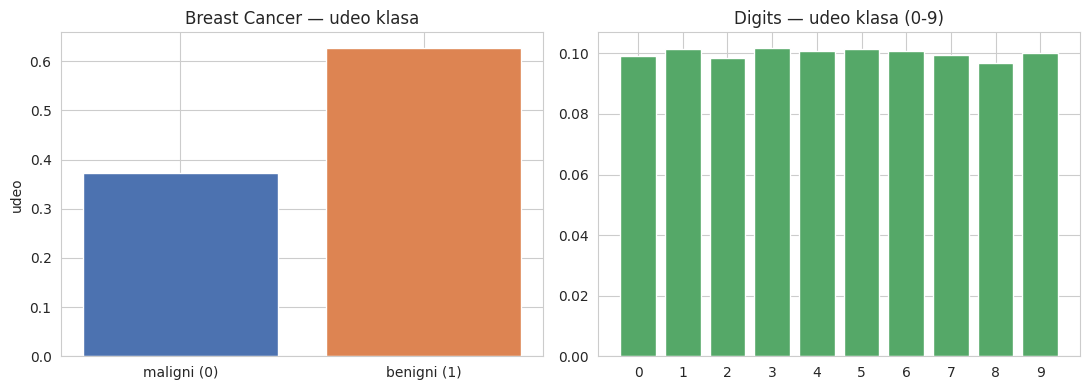

Breast cancer udeli:
0    0.372583
1    0.627417
Name: proportion, dtype: float64


In [12]:
udeli_bc = pd.Series(y_bc).value_counts(normalize=True).sort_index()
udeli_dg = pd.Series(y_dg).value_counts(normalize=True).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['maligni (0)', 'benigni (1)'], udeli_bc.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Breast Cancer — udeo klasa')
axes[0].set_ylabel('udeo')

axes[1].bar(udeli_dg.index.astype(str), udeli_dg.values, color='#55A868')
axes[1].set_title('Digits — udeo klasa (0-9)')

plt.tight_layout()
plt.show()

print('Breast cancer udeli:')
print(udeli_bc)

Vidimo da Breast Cancer nije potpuno balansiran (skoro 63% : 37%), dok je Digits skup približno ravnomerno raspoređen po sve 3 klase... odnosno 10 klasa cifara.

## 4. Zanimljiva svojstva podataka

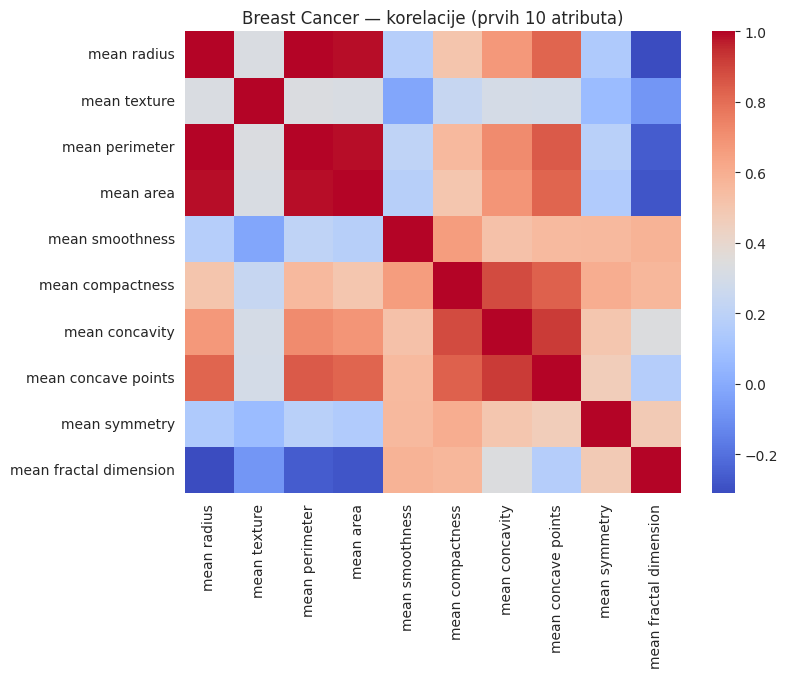

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_bc.iloc[:, :10].corr(), annot=False, cmap='coolwarm')
plt.title('Breast Cancer — korelacije (prvih 10 atributa)')
plt.show()

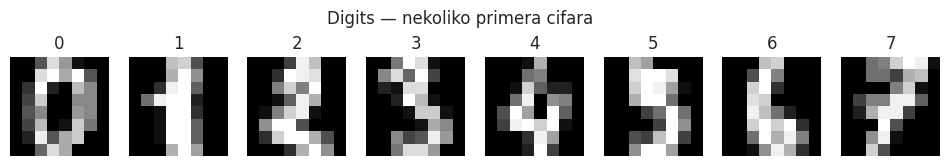

In [14]:
fig, axes = plt.subplots(1, 8, figsize=(12, 2))

for i in range(8):
    slika = X_dg[i].reshape(8, 8) 
    axes[i].imshow(slika, cmap='gray')
    axes[i].set_title(str(y_dg[i]))
    axes[i].axis('off')

plt.suptitle('Digits — nekoliko primera cifara')
plt.show()